# <font color=#2e86c1> What's Liouville space? </font>

<a href="https://githubtocolab.com/alsinmr/ConferenceExamples/blob/master/JupyterBook/Ampere2026/LiouvilleSpace_colab.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg"></a>

Before we answer that question, let's review the more familiar Hilbert space.
## Hilbert space
Suppose we have a Hamiltonian, $\hat{H}$, in Hilbert space. For a simulation, that means we have an $m\times m$ matrix in our computer memory representing the Hamiltonian. In this case, $m=\prod_{i=1}^N{(2*S_i+1)}$, where $S_i$ is the spin of the $i^{th}$ nucleus or electron. Let's have a look at this in SLEEPY.


In [2]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub/SLEEPY/')

In [3]:
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt

Loading Defaults from file


Below, we look at a Hamiltonian. The two spin-1/2 system gives a 4x4 matrix ($m=(2*1/2+1)*(2*1/2+1)=4$)

In [4]:
ex=sl.ExpSys(600,Nucs=['1H','1H'])
ex.set_inter('CS',i=0,ppm=1)
ex.set_inter('CS',i=0,ppm=5)
ex.set_inter('J',i0=0,i1=1,J=200)
H=ex.Hamiltonian()

In [5]:
H.H()

array([[ 1550.+0.j,     0.+0.j,     0.+0.j,     0.+0.j],
       [    0.+0.j,  1450.+0.j,   100.+0.j,     0.+0.j],
       [    0.+0.j,   100.+0.j, -1550.+0.j,     0.+0.j],
       [    0.+0.j,     0.+0.j,     0.+0.j, -1450.+0.j]])

We can also visualize the Hamiltonian:

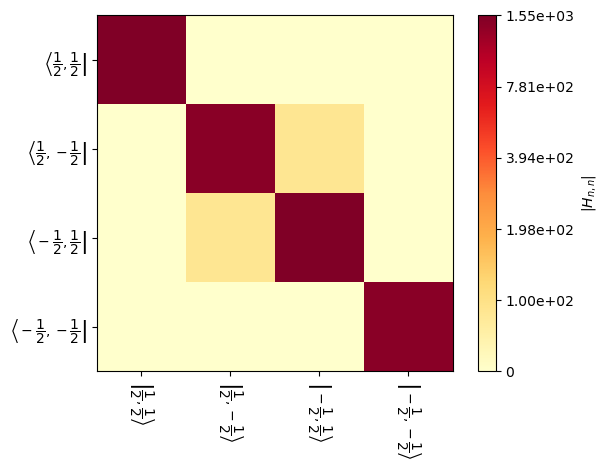

In [6]:
_=H.plot()

In Hilbert space, the current state of the spin system is described by a square density matrix (also $mxm$), often denoted with $\hat{\rho}(t)$. Diagonal elements of the density matrix specify how much population is in each of the eigenstates of the Zeeman Hamiltonian, and off-diagonal elements specify populations of coherences between those  states. $\hat{\rho}(t)$ will evolve in time depending on the Hamiltonian, according to:

$$
\begin{equation}
\hat{\rho}(t+\Delta t)=\exp{(-i\hat{H}\Delta t)}\hat{\rho}(t)\exp{(i\hat{H}\Delta t)}
\end{equation}
$$

Note, here we assume a time-independent Hamiltonian. In SLEEPY simulations, we handle time-dependence by breaking simulations into small, time-independent steps, a common approach in NMR simulation. Note that to propagate the density matrix, we have sandwiched it between two matrix exponentials. 

*A few notes of caution:* First, these operations require matrix multiplication, not elementwise multiplication, and where the $\exp$ indicates a matrix exponential, not an elementwise exponential. In MATLAB, one obtains the matrix exponential with expm. In Python, we need the scipy module, and run `from scipy.linalg import expm` to also obtain this function. Second, our notation here assumes the Hamiltonian in radians/s, not Hz, which would require multiplying by $2\pi$.

Often, we define a propagator, such that

$$
\begin{eqnarray}
\hat{U}(\Delta t)&=&\exp{(-i\hat{H} \Delta t)} \\
\hat{\rho}(t+\Delta t)&=&\hat{U}(\Delta t)\hat{\rho}(t)\hat{U}^\dagger(\Delta t)
\end{eqnarray}
$$

So, here arises the problem with Hilbert space: It is not straightforward to create a system that exchanges between two or more Hamiltonians in a stochastic manner when we have the square density matrix and sandwiched multiplication. This brings us to Liouville space.

## Liouville space
Liouville space may be constructed from Hilbert space, by first stretching the $m\times m$ density matrix into a length $m^2$ vector, and second, calculating the coherent Liouvillian from the Hamiltonian, according to

$$
\begin{equation}
\hat{\hat{L}}_{coh}=-i*(\hat{H}\otimes\hat{\mathbf{1}}-\hat{\mathbf{1}}\otimes\hat{H}^T)
\end{equation}
$$

In the above equation, $\otimes$ is the [Kronecker product](https://en.wikipedia.org/wiki/Kronecker_product), $\hat{\mathbf{1}}$ is an identity matrix with the same dimensions as the Hamiltonian, and $\hat{H}^T$ is the transpose (not the complex transpose!) of the Hamiltonian. The result is an $m^2\times m^2$ matrix. In SLEEPY, we absorb the factor of $-i$ into the Liouvillian, although one may also keep this separate.

We plot the result in SLEEPY below.

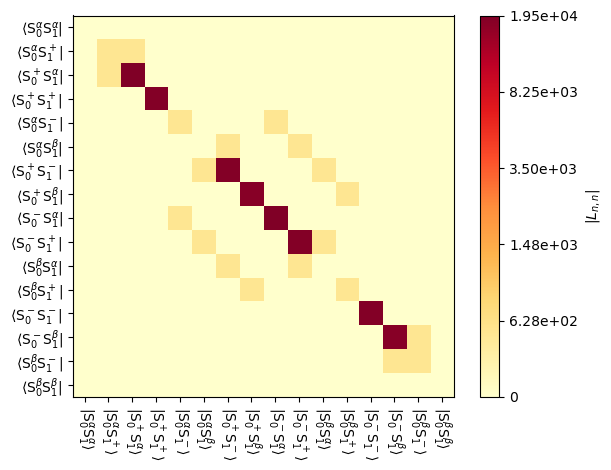

In [11]:
L=H.Liouvillian()
_=L.plot()

### Dissipative terms in Liouville space: Relaxation

The main advantage of working in Liouville space is that we can introduce dissipative terms (i.e. non-coherent) that induce exchange or relaxation. For example, in the above Liouvillian, we can introduce $T_2$ relaxation to both spins, so that the total Liouvillian becomes

$$
\begin{equation}
\hat{\hat{L}}_{total}=\hat{\hat{L}}_{coh}+\hat{\hat{L}}_{relax}
\end{equation}
$$

Below, we plot $\hat{\hat{L}}_{relax}$

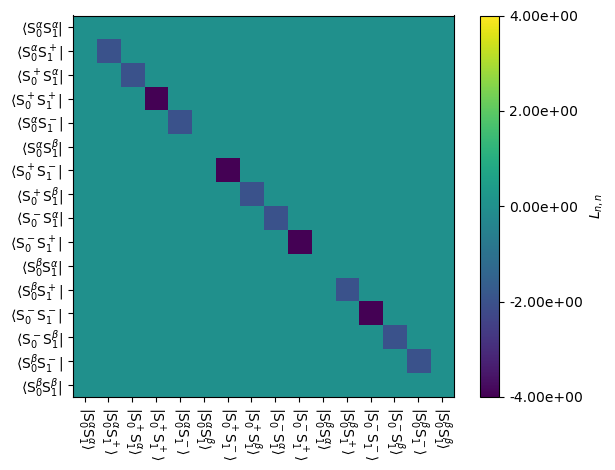

In [12]:
L.add_relax('T2',i=0,T2=.5)
L.add_relax('T2',i=1,T2=.5)
_=L.plot('Lrelax',mode='re')

The result is negative terms on the diagonal where coherences are found, which will gradually destroy those terms. We may also add $T_1$ relaxation to see its effect.

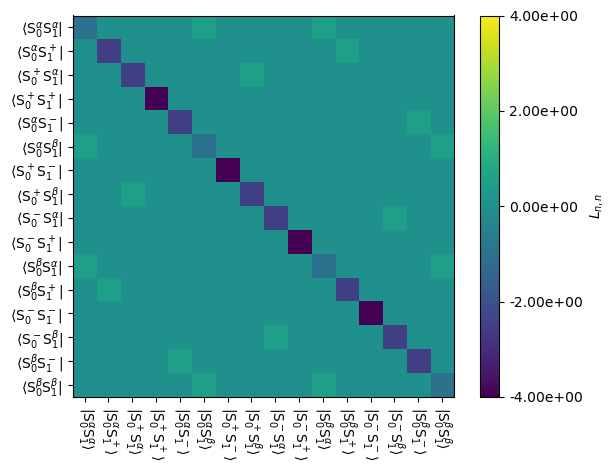

In [13]:
L.add_relax('T1',i=0,T1=1)
L.add_relax('T1',i=1,T1=1)
_=L.plot('Lrelax',mode='re')

The result is off-diagonal terms that are coupling $\alpha$ to $\beta$ states, which effectively drives $T_1$ relaxation.

### Dissipative terms in Liouville space: Exchange

We may also introduce dynamics into SLEEPY via exchange. Here, we copy the ExpSys object and modify one of the chemical shifts, then build a Liouvillian with exchange.

The exchange matrix needs to have columns that sum to 0. Here, we introduce symmetric exchange (equal populations). One may also use various tools in SLEEPY to build exchange matrices or Liouvillians directly (see `sl.Tools`)

In [14]:
ex1=ex.copy()
ex.set_inter('CS',i=0,ppm=3)
L=sl.Liouvillian(ex,ex1)
L.kex=[[-20,20],[20,-20]]

Now, the total Liouvillian also contains an exchange term, such that

$$
\begin{equation}
\hat{\hat{L}}_{total}=\hat{\hat{L}}_{coh}+\hat{\hat{L}}_{relax}+\hat{\hat{L}}_{ex}
\end{equation}
$$

We plot the exchange part of the Liouvillian below:

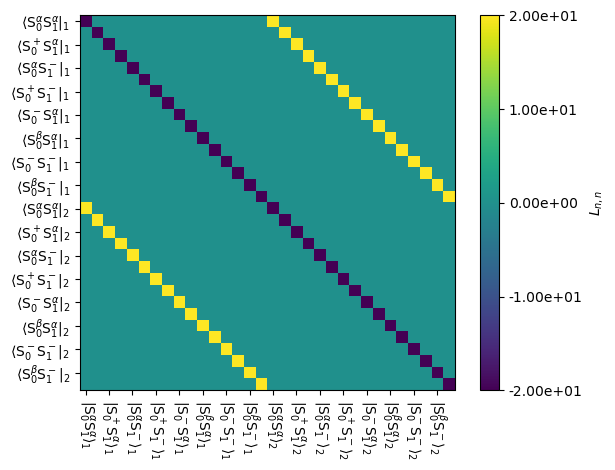

In [16]:
_=L.plot('Lex',mode='re')

## Propagation with the Liouvillian

In Liouville space, a propagator is calculated according to

$$
\begin{equation}
\hat{\hat{U}} (\Delta t)=\exp{(\Delta t\hat{\hat{L}})}
\end{equation}
$$

The density matrix is reshaped into a column vector, at which point propagation can be calculated as follows:

$$
\begin{equation}
\hat{\rho}(t+\Delta t)=\hat{\hat{U}} (\Delta t)\hat{\rho}(t)
\end{equation}
$$

So, sandwiching the density matrix is no longer required in Liouville space